In [ ]:
%matplotlib widget

import csv
import requests
from pathlib import Path
import os, re
import traceback
from moku.instruments import FrequencyResponseAnalyzer

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from uncertainties import ufloat

## Estilo dos gráficos ##########################################################################################

plt.style.use('default') # Gráficos com fundo branco
# plt.rcParams["figure.autolayout"] = True
# plt.rcParams["figure.figsize"] = [16, 9] # [7, 4] # [8, 5]
plt.style.use({
    'figure.figsize': [7,4], 'figure.constrained_layout.use': True, #'text.usetex' : True,
    'axes.titlesize': 14, 'legend.fontsize': 10, 'axes.labelsize': 12,'xtick.labelsize': 10, 'ytick.labelsize': 10,
})

In [ ]:
## CONEXÃO E COLETA DE DADOS ####################################################################################

MOKU_IP = '192.168.73.1' # IP do equipamento
FRA = None # Garante que a variável existe, mesmo se a conexão explodir. FRA: Frequency Response Analyzer
arquivo_csv = Path.cwd() / 'Dados_Passa_Alta.csv'

try:
    print(f"Buscando o Moku:Go na rede pelo IP: {MOKU_IP} ...")
    FRA = FrequencyResponseAnalyzer(MOKU_IP, force_connect=True) # 'force_connect=True' garante controle mesmo com o app aberto
    print("Conexão bem-sucedida! Configurando o instrumento ...")
    
    # 1. Configura a varredura
    FRA.set_defaults()
    FRA.set_frontend(1, impedance='1MOhm', coupling='DC', range='10Vpp')
    FRA.set_frontend(2, impedance='1MOhm', coupling='DC', range='10Vpp')
    FRA.set_sweep(
        start_frequency=100, stop_frequency=100e3, num_points=256,
        settling_cycles=2, averaging_cycles=2, strict=False
    )
    FRA.set_output(1, amplitude=1.0, offset=0.0)
    
    # 3. Inicia a varredura, espera terminar e extrai os dados
    print("Iniciando varredura ... (Script em espera)")
    FRA.start_sweep()
    Data = FRA.get_data(wait_complete=True)
    
    # 4. Extração pelas Chaves da API e Tratamento dos Dados (Convertendo saída do Moku para Arrays)
    Freqs     = np.array(Data['ch1']['frequency'])
    Mag_ch1   = np.array(Data['ch1']['magnitude'])
    Mag_ch2   = np.array(Data['ch2']['magnitude'])
    phase_ch1 = np.array(Data['ch1']['phase'])
    phase_ch2 = np.array(Data['ch2']['phase'])
    
    # A atenuação real do filtro (CH2 - CH1) --> Magnitude (dB) = 20 * log10(|Vout/Vin|) = Mag_CH2(dB) - Mag_CH1(dB)
    Transf_mag = Mag_ch2 - Mag_ch1
    Transf_phase = np.rad2deg( np.unwrap( np.deg2rad(phase_ch2 - phase_ch1) ) ) # Unwrap da fase para evitar saltos de 360 graus

    # Força o teto experimental a ser 0 dB para remover os 20dB de ganho fantasma do MokuGo
    Offset_residual = Transf_mag.max()
    Transf_mag = Transf_mag - Offset_residual

    # 5. Exportando backup para CSV
    print("Exportando para CSV...")
    df_export = pd.DataFrame({
        'Frequency_Hz'    : Freqs,
        'Magnitude_CH1'   : Mag_ch1,
        'Magnitude_CH2'   : Mag_ch2,
        'Phase_CH1'       : phase_ch1,
        'Phase_CH2'       : phase_ch2,
        'Transf_Magnitude': Transf_mag,
        'Transf_Phase'    : Transf_phase
    })
    
    df_export.to_csv(arquivo_csv, index=False)
    print(f"Arquivo salvo com sucesso em:\n{arquivo_csv}")

except Exception as e:
    traceback.print_exc()

finally: # Libera o instrumento para não travar o Moku:Go
    if FRA is not None: # Só libera se o instrumento estava conectado
        FRA.relinquish_ownership()
        print("Conexão encerrada")

DIVERGÊNCIA TEÓRICA EXPERIMENTAL
Abs.: 115.04Hz  | Rel.: 3.12 %
T_pass: 0.03 dB  | Tc: -2.97 dB


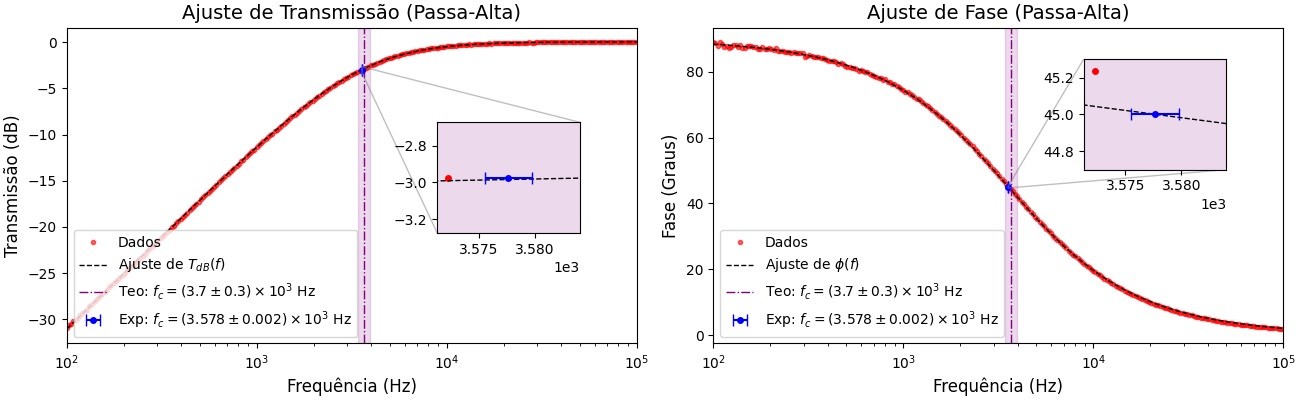

In [ ]:
## OTIMIZAÇÃO DE CURVA E PLOTAGEM (Curve Fit) ###################################################################

# Valores e Tolerâncias nominais dos componentes (datasheet)
R_teo, C_teo = 4.31e3, 10e-9
tol_R, tol_C = 0.05, 0.05 # percentil
sig_R = R_teo * tol_R
sig_C = C_teo * tol_C

# Cálculo teórico e propagação de incerteza
fc_teo     = 1 / (2 * np.pi * R_teo * C_teo)
sig_fc_teo = fc_teo * np.sqrt((sig_R / R_teo)**2 + (sig_C / C_teo)**2)
fc_teo_inc = ufloat(fc_teo, sig_fc_teo)

# 1. Lendo os dados do arquivo CSV offline
arquivo_csv = Path.cwd() / 'Dados_Passa_Alta.csv'
df_import   = pd.read_csv(arquivo_csv)

df = pd.DataFrame({ # Mapeando as colunas do CSV para o DataFrame da plotagem
    'Frequencia' : df_import['Frequency_Hz'],
    'Transmissao': df_import['Transf_Magnitude'],
    'Fase'       : df_import['Transf_Phase']
})

# 2. Definindo o modelo matemático com correção experimental
def Calc_Transmissao(f, fc, T_pass):
    return 20 * np.log10(f / fc) - 10 * np.log10( 1 + (f / fc)**2 ) + T_pass

def Calc_Fase(f, fc):
    return np.rad2deg( np.arctan(fc / f) )

# 3. Palpites Iniciais (p0) Dinâmicos
T_pass = df['Transmissao'].max()                 # Transmissão na banda de passagem (máximo; idealmente T ~ 0dB)
Tc     = T_pass - 3                              # Transmissão de corte (queda de 3dB; idealmente T ~ -3dB)
idx_fc = (df['Transmissao'] - Tc).abs().argmin() # Índice da queda de 3dB
fc     = df['Frequencia'].iloc[idx_fc]           # Frequência de corte (queda de 3dB)

# 4. Ajuste Fino (Curve Fit)
popt, pcov = curve_fit(
    f=Calc_Transmissao, xdata=df['Frequencia'], ydata=df['Transmissao'],
    p0=[fc, T_pass], bounds=([0, -np.inf], [np.inf, np.inf]) # fc > 0, T_dB livre
)
fc_exp, T_pass_opt = popt # Parâmetros Otimizados

sig_fc_exp = np.sqrt(pcov[0, 0]) # Diagonal da matriz de covariância é a variância dos parâmetros.
fc_exp_inc = ufloat(fc_exp, sig_fc_exp)

Tc_exp = T_pass_opt - 3
Fc_exp = Calc_Fase(fc_exp, fc_exp)

print("DIVERGÊNCIA TEÓRICA EXPERIMENTAL") # .center(40, "=")
print(f"Abs.: {abs(fc_exp - fc_teo):.2f}Hz  | Rel.: {abs(fc_exp - fc_teo)/fc_teo*100:.2f} %")
print(f"T_pass: {T_pass_opt:.2f} dB  | Tc: {Tc_exp:.2f} dB")

# 5. Plotagem Estilo Artigo Científico
df['Fit_Transmissao'] = Calc_Transmissao(df['Frequencia'], fc_exp, T_pass_opt)
df['Fit_Fase'] = Calc_Fase(df['Frequencia'], fc_exp)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4), sharex=True)

# GRÁFICO 1: TRANSMISSÃO ========================================================================================
ax1.semilogx(df['Frequencia'], df['Transmissao'], 'ro', label='Dados', markersize=3, alpha=0.6)
ax1.semilogx(df['Frequencia'], df['Fit_Transmissao'], 'k--', label='Ajuste de $T_{dB}(f)$', linewidth=1)
ax1.axvline(fc_teo, color='purple', linestyle='-.', label=f'Teo: $f_c = {fc_teo_inc:.1ueL}$ Hz', linewidth=1)
ax1.axvspan(fc_teo - sig_fc_teo, fc_teo + sig_fc_teo, color='purple', alpha=0.15)
ax1.errorbar(fc_exp, Tc_exp, xerr=sig_fc_exp, fmt='bo', label=f'Exp: $f_c = {fc_exp_inc:.1ueL}$ Hz',  capsize=4, markersize=4)
ax1.set_title('Ajuste de Transmissão (Passa-Alta)')
ax1.set_xlabel('Frequência (Hz)')
ax1.set_ylabel('Transmissão (dB)')
ax1.tick_params(axis='both', which='major')
ax1.legend(loc='lower left')
ax1.set_xlim(min(df['Frequencia']), max(df['Frequencia']))

# Inset (Janela de Zoom)
axins1 = ax1.inset_axes([0.65, 0.35, 0.25, 0.35]) # [posição_x, posição_y, largura, altura]; tudo em proporção de 0 a 1
axins1.plot(df['Frequencia'], df['Transmissao'], 'ro', markersize=4)  # Escala linear ('plot' no lugar de 'semilogx')
axins1.plot(df['Frequencia'], df['Fit_Transmissao'], 'k--', linewidth=1) # Escala linear ('plot' no lugar de 'semilogx')
axins1.axvline(fc_teo, color='purple', linestyle='-.')
axins1.axvspan(fc_teo - sig_fc_teo, fc_teo + sig_fc_teo, color='purple', alpha=0.15)
axins1.errorbar(fc_exp, Tc_exp, xerr=sig_fc_exp, fmt='bo', capsize=4, markersize=4)
axins1.set_xlim(fc_exp - 3*sig_fc_exp, fc_exp + 3*sig_fc_exp) # Limites do zoom
axins1.set_ylim(Tc_exp - 0.3, Tc_exp + 0.3)                   # Limites do zoom
axins1.ticklabel_format(axis='x', style='sci', scilimits=(0,0))

indicador1 = ax1.indicate_inset_zoom(axins1, edgecolor="gray")
indicador1.connectors[0].set_visible(True)  # Inferior Esquerdo
indicador1.connectors[1].set_visible(False) # Superior Esquerdo
indicador1.connectors[2].set_visible(False) # Inferior Direito
indicador1.connectors[3].set_visible(True)  # Superior Direito

# GRÁFICO 2: FASE ===============================================================================================
ax2.semilogx(df['Frequencia'], df['Fase'], 'ro', label='Dados', markersize=3, alpha=0.6)
ax2.semilogx(df['Frequencia'], df['Fit_Fase'], 'k--', label='Ajuste de $\\phi(f)$', linewidth=1)
ax2.axvline(fc_teo, color='purple', linestyle='-.', label=f'Teo: $f_c = {fc_teo_inc:.1ueL}$ Hz', linewidth=1)
ax2.axvspan(fc_teo - sig_fc_teo, fc_teo + sig_fc_teo, color='purple', alpha=0.15)
ax2.errorbar(fc_exp, Fc_exp, xerr=sig_fc_exp, fmt='bo', label=f'Exp: $f_c = {fc_exp_inc:.1ueL}$ Hz', capsize=4, markersize=4)
ax2.set_title('Ajuste de Fase (Passa-Alta)')
ax2.set_xlabel('Frequência (Hz)')
ax2.set_ylabel('Fase (Graus)')
ax2.legend(loc='lower left')

# Inset (Zoom) - Canto superior direito (longe da curva que já desceu para perto de 0)
axins2 = ax2.inset_axes([0.65, 0.55, 0.25, 0.35]) 
axins2.plot(df['Frequencia'], df['Fase'], 'ro', markersize=4)
axins2.plot(df['Frequencia'], df['Fit_Fase'], 'k--', linewidth=1)
axins2.axvline(fc_teo, color='purple', linestyle='-.', linewidth=1)
axins2.axvspan(fc_teo - sig_fc_teo, fc_teo + sig_fc_teo, color='purple', alpha=0.15)
axins2.errorbar(fc_exp, Fc_exp, xerr=sig_fc_exp, fmt='bo', capsize=4, markersize=4)
axins2.set_xlim(fc_exp - 3*sig_fc_exp, fc_exp + 3*sig_fc_exp)
axins2.set_ylim(Fc_exp - 0.3, Fc_exp + 0.3)
axins2.ticklabel_format(axis='x', style='sci', scilimits=(0,0))

indicador2 = ax2.indicate_inset_zoom(axins2, edgecolor="gray")
indicador2.connectors[0].set_visible(False) # Inferior Esquerdo
indicador2.connectors[1].set_visible(True)  # Superior Esquerdo
indicador2.connectors[2].set_visible(True)  # Inferior Direito
indicador2.connectors[3].set_visible(False) # Superior Direito
